In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from tqdm import tqdm
from scipy.optimize import fsolve
import pandas as pd
import plotly.express as px
import matplotlib
from matplotlib.colors import LogNorm, PowerNorm

In [2]:
# DEFINE STANDARD FORMATING FOR FIGURES USED THROUGHOUT PAPER
sns.set(style="white",font_scale=2.5,palette="colorblind")
plt.rcParams['lines.linewidth'] = 4
plt.rcParams["figure.figsize"] = (12, 10)

# **Necessary Functions**



In [ ]:
def M_kappa(x, kappa):
    return 2 / ( (x + 1 - 1/kappa) + np.sqrt((x + 1 - 1/kappa)**2 + 4*x/kappa) )

def ridgeless_icl(tau, alpha, rho, kappa):
    x_star = (1 + rho) / alpha
    m_star = M_kappa(x_star, kappa)
    mu_star = x_star * M_kappa(x_star, kappa/tau)

    if tau < 1:
        result = tau * (1 + x_star) / (1 - tau) * (1 - tau * (1 - mu_star)**2 - (x_star - rho) / x_star * mu_star ) - 2 * tau * (1 - mu_star) + rho + 1
    else:
        k_star = (1 - kappa * (m_star / (kappa + m_star))**2)**-1
        term1 = (k_star - 1/(tau - 1)) * (1 + x_star) * (x_star * m_star)**2
        term2 = (3 - 2 * tau) / (tau - 1) * m_star * (x_star)**2
        term3 = ((1 + rho) / (tau - 1) * m_star + 1) * x_star + rho * m_star / (tau - 1) + rho

        result = term1 + term2 + term3

    return result

from ast import Return
def ridgeless_idg(alpha, t, psi, sigma, kappa):
  rho = (sigma/psi)**2
  Xstar = (1 + rho)/alpha
  mstar = 2/(Xstar + 1 - 1/kappa + np.sqrt(4*Xstar/kappa + (Xstar + 1 - 1/kappa)**2))
  mustar = 2*Xstar/(Xstar + 1 - t/kappa + np.sqrt(4*Xstar*t/kappa + (Xstar + 1 - t/kappa)**2))

  answer = 0;
  if t < 1:
    eps = (1-t)*Xstar/(t*mustar)
    c = 1/(1 - kappa/(1+kappa*eps/(1-t))**2)
    answer = (Xstar + eps)**2/eps + (rho+Xstar-2*Xstar*(1-t)*(Xstar/eps + 1))/(1-t-c*(1-t)**2)
  else:
    answer = (rho + Xstar*(1-Xstar*mstar))/(t-1)
  return t*answer

def S_Wishart(x, nu):
    """
    This funciton computes the Stieltjes transform of the Wishart distribution.
    """
    sigma_beta = 1;
    return 2/sigma_beta**2 / ((x/sigma_beta**2 + 1 - 1/nu) + np.sqrt((x/sigma_beta**2 + 1 - 1/nu)**2 + 4 * x/sigma_beta**2/nu))

def S_Wishart_derivative(x, nu):
    """
    This funciton computes the derivative of the Stieltjes transform of the Wishart distribution.
    """
    sigma_beta = 1
    s = S_Wishart(x, nu)
    return -1/2 * s**2 * (1 + (x/sigma_beta**2 + 1 + 1/nu)/np.sqrt((x/sigma_beta**2 + 1 - 1/nu)**2 + 4 * x/sigma_beta**2/nu))

def prop_idg(tau, alpha, kappa, rho):
  q = (1 + rho)/alpha
  m = S_Wishart(q, kappa)
  mu = q * S_Wishart(q, kappa/tau)

  answer = 0;
  if tau < 1:
    eps = (1-tau)*q/(tau*mu)
    p = 1 - kappa*(1+kappa*eps/(1-tau))**(-2); p = 1/p
    answer = (tau/(1-tau)) * ( tau*mu*((q+eps)**2)/q  +  (rho + q - 2*q*(1-tau)*(q/eps + 1)) / (1-p*(1-tau)))
    return answer
  else:
    answer = (rho + q*(1-q*m))/(tau-1)
    return tau*answer

def self_consistency(eps, x, tau, kappa, ridge):
    return 1 - tau + tau*ridge/eps - eps*S_Wishart(eps+x,kappa)

def self_consistency_polynomial(x, tau, kappa, ridge):
    k = kappa; t = tau; l = ridge;
    p = np.zeros(5);
    p[4] = k*t
    p[3] = (-k*l*t + k*t*x + k*t - k*x - t**2 - k + t)
    p[2] = (-k*l*t*x - k*l*t + 2*l*t**2 - (t**2)*x - l*t + 2*t*x - x)
    p[1] = (-(l**2)*(t**2) + 2*l*(t**2)*x - 2*l*t*x)
    p[0] = -l**2*t**2*x
    return p

def full_lambda(tau, alpha, kappa, rho, ridge, cheat):
  p = self_consistency_polynomial((1+rho)/alpha, tau, kappa, ridge)
  eps_vals = np.roots(p);
  eps = np.min(eps_vals[eps_vals>0])
  if eps < 0.027:
    eps = ridge
  if cheat:
    eps = ridge
  nu = (1+rho)/alpha + eps
  c_e = (rho + nu - nu**2 * S_Wishart(nu, kappa) - eps * (1 - 2 * nu * S_Wishart(nu, kappa) - nu**2 * S_Wishart_derivative(nu, kappa))) / (1 - 2 * eps * S_Wishart(nu, kappa) - eps**2 * S_Wishart_derivative(nu, kappa) - tau)
  ans = ((1 + rho) / alpha + 1) * (1 - 2 * nu * S_Wishart(nu, kappa) - nu**2 * S_Wishart_derivative(nu, kappa) - c_e * (S_Wishart(nu, kappa) + eps * S_Wishart_derivative(nu, kappa))) - 2 * (1 - nu * S_Wishart(nu, kappa)) + 1 + rho
  return ans


In [ ]:
def is_monotonic_or_flat(arr):
    increasing = decreasing = True
    eps = 0.00001
    # Check if the array is monotonic or flat
    for i in range(1, len(arr)):
        if arr[i] > arr[i - 1] + eps:
            decreasing = False
        if arr[i] < arr[i - 1] - eps:
            increasing = False

    if increasing or decreasing:
        return 0

    # Find a local minimum
    for i in range(1, len(arr) - 1):
        if arr[i - 1] > arr[i] < arr[i + 1]:
            return i

    # If no local minimum is found (which shouldn't normally happen), return the index of the global minimum as a fallback
    return arr.index(min(arr))

# **Heatmap plot of nonmontonicity**

In [ ]:
tau = 0.5;
kappas = np.linspace(0.1,2.1,401)
alphas = np.logspace(np.log10(0.01),np.log10(1000),500)
rhos = np.linspace(0.01,1,300)
valsicl0p5 = np.zeros((len(rhos),len(kappas),len(alphas)))
valsidg0p5 = np.zeros((len(rhos),len(kappas),len(alphas)))
valsicl20 = np.zeros((len(rhos),len(kappas),len(alphas)))
mins_icl_0p5 = np.zeros((len(rhos),len(kappas)))
mins_idg_0p5 = np.zeros((len(rhos),len(kappas)))
mins_icl_20 = np.zeros((len(rhos),len(kappas)))

for p in tqdm(range(len(rhos))):
  rho = rhos[p]
  for k in range(len(kappas)):
    kappa = kappas[k];
    for a in range(len(alphas)):
      alpha = alphas[a];
      valsicl0p5[p,k,a] = ridgeless_icl(0.5,alpha,rho,kappa)
      valsidg0p5[p,k,a] = ridgeless_idg(alpha, 0.5, 1, np.sqrt(rho), kappa)
      valsicl20[p,k,a] = ridgeless_icl(20,alpha,rho,kappa)
    mins_icl_0p5[p,k] = is_monotonic_or_flat(valsicl0p5[p,k,:])
    mins_idg_0p5[p,k] = is_monotonic_or_flat(valsidg0p5[p,k,:])
    mins_icl_20[p,k] = is_monotonic_or_flat(valsicl20[p,k,:])


100%|██████████| 300/300 [29:12<00:00,  5.84s/it]


In [ ]:
from matplotlib.colors import PowerNorm

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

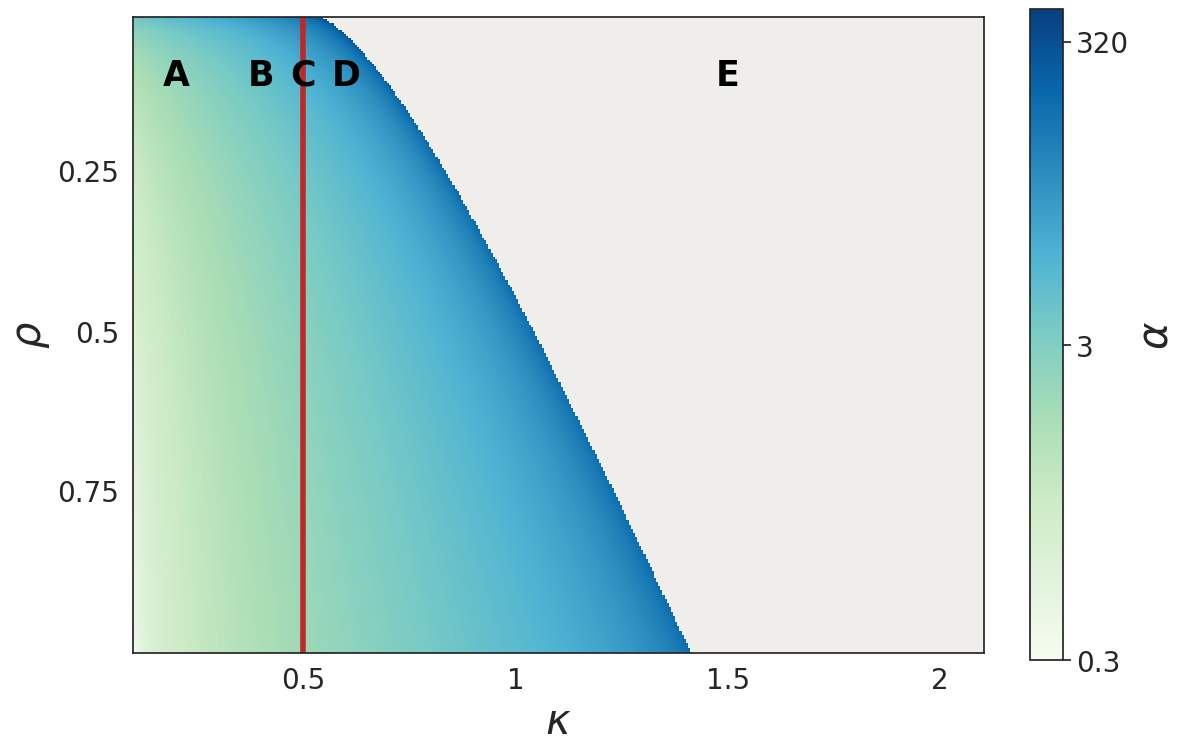

In [ ]:
value = 0
masked_array = np.ma.masked_where(mins_icl_0p5 == value, mins_icl_0p5)
cmap = matplotlib.cm.GnBu # Can be any colormap that you want after the cm
cmap.set_bad(color='#EFEEEA')

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the data using imshow
im = ax.imshow(masked_array, cmap=cmap, norm=PowerNorm(gamma=0.5))#, norm=LogNorm(vmin=np.min(masked_array[masked_array > 0]), vmax=np.max(masked_array)))
rhocoord = np.abs(rhos - 0.1).argmin()
coordinates = [(np.abs(kappas - 0.2).argmin(), rhocoord), (np.abs(kappas - 0.4).argmin(), rhocoord), (np.abs(kappas - 0.5).argmin(), rhocoord), (np.abs(kappas - 0.6).argmin(), rhocoord), (np.abs(kappas - 1.5).argmin(),rhocoord)]  # Example: (row, column) coordinates
labels = ['A', 'B', 'C', 'D', 'E']
for (x, y), label in zip(coordinates, labels):
    ax.text(x, y, label, ha='center', va='center', color='black', fontsize=25, fontweight='bold')

# Create the colorbar with the same height as the plot
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.05)
cbar.ax.set_yticks([150,250,450])  # Remove ticks
cbar.ax.set_yticklabels([0.3,3,320])  # Remove tick labels
cbar.ax.set_ylabel(r'$\alpha$')

xvals = [0.5,1,1.5,2]
indsx = [np.abs(kappas - val).argmin() for val in xvals]
yvals = [0.25,0.5,0.75]
indsy = [np.abs(rhos - val).argmin() for val in yvals]

plt.xticks(ticks=indsx, labels=xvals)
plt.yticks(ticks=indsy, labels=yvals)
plt.xticks(fontsize=20);
plt.yticks(fontsize=20);
cbar.ax.tick_params(labelsize=20)  # Set the desired font size
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$\rho$')

plt.axvline(np.abs(kappas - np.min([tau,1])).argmin(),linestyle='-',linewidth=4,color='#BF2828',label=r'min($\tau$,1)')

plt.savefig("nonmonotonic_ICL_0p5.pdf", bbox_inches='tight')
files.download("nonmonotonic_ICL_0p5.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

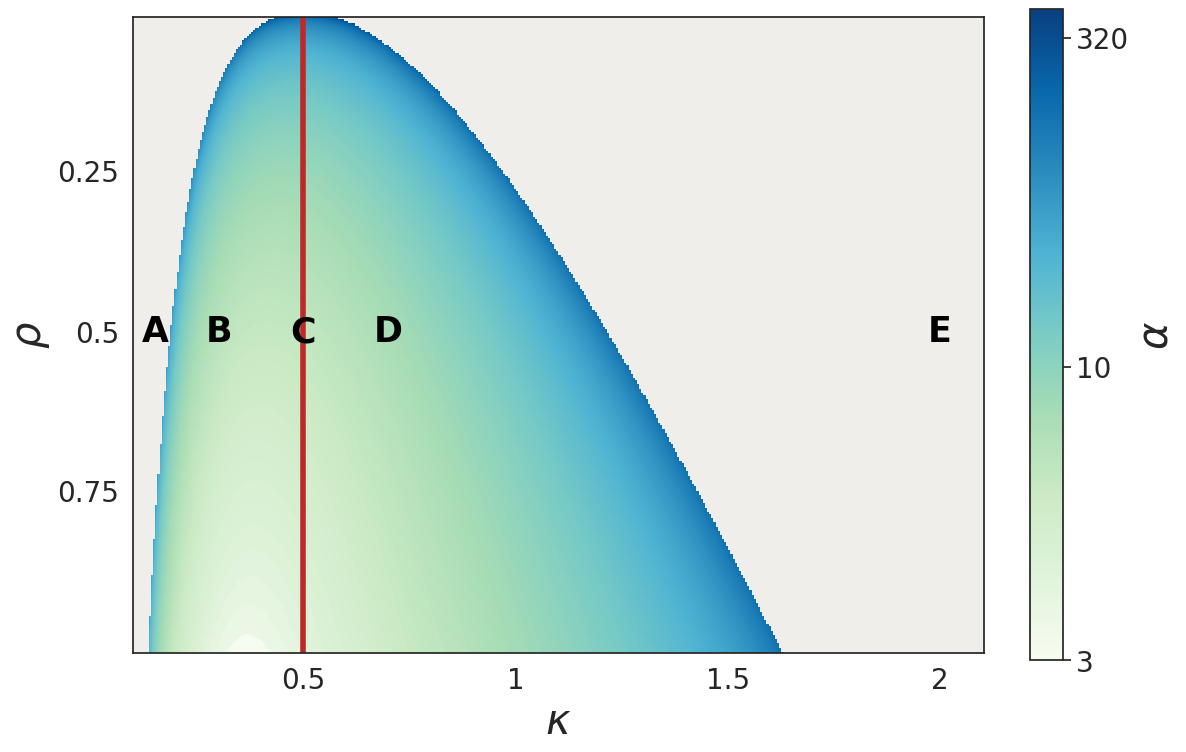

In [ ]:
value = 0
masked_array = np.ma.masked_where(mins_idg_0p5 == value, mins_idg_0p5)
cmap = matplotlib.cm.GnBu # Can be any colormap that you want after the cm
cmap.set_bad(color='#EFEEEA')

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the data using imshow
im = ax.imshow(masked_array, cmap=cmap, norm=PowerNorm(gamma=0.5))#, norm=LogNorm(vmin=np.min(masked_array[masked_array > 0]), vmax=np.max(masked_array)))
rhocoord = np.abs(rhos - 0.5).argmin()
coordinates = [(np.abs(kappas - 0.15).argmin(), rhocoord), (np.abs(kappas - 0.3).argmin(), rhocoord), (np.abs(kappas - 0.5).argmin(), rhocoord), (np.abs(kappas - 0.7).argmin(), rhocoord), (np.abs(kappas - 2).argmin(),rhocoord)]  # Example: (row, column) coordinates
labels = ['A', 'B', 'C', 'D', 'E']
for (x, y), label in zip(coordinates, labels):
    ax.text(x, y, label, ha='center', va='center', color='black', fontsize=25, fontweight='bold')

# Create the colorbar with the same height as the plot
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.05)
cbar.ax.set_yticks([250,300,450])  # Remove ticks
cbar.ax.set_yticklabels([3,10,320])  # Remove tick labels
cbar.ax.set_ylabel(r'$\alpha$')

xvals = [0.5,1,1.5,2]
indsx = [np.abs(kappas - val).argmin() for val in xvals]
yvals = [0.25,0.5,0.75]
indsy = [np.abs(rhos - val).argmin() for val in yvals]

plt.xticks(ticks=indsx, labels=xvals)
plt.yticks(ticks=indsy, labels=yvals)
plt.xticks(fontsize=20);
plt.yticks(fontsize=20);
cbar.ax.tick_params(labelsize=20)  # Set the desired font size
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$\rho$')

plt.axvline(np.abs(kappas - np.min([tau,1])).argmin(),linestyle='-',linewidth=4,color='#BF2828',label=r'min($\tau$,1)')

plt.savefig("nonmonotonic_ICL_0p5.pdf", bbox_inches='tight')
files.download("nonmonotonic_ICL_0p5.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

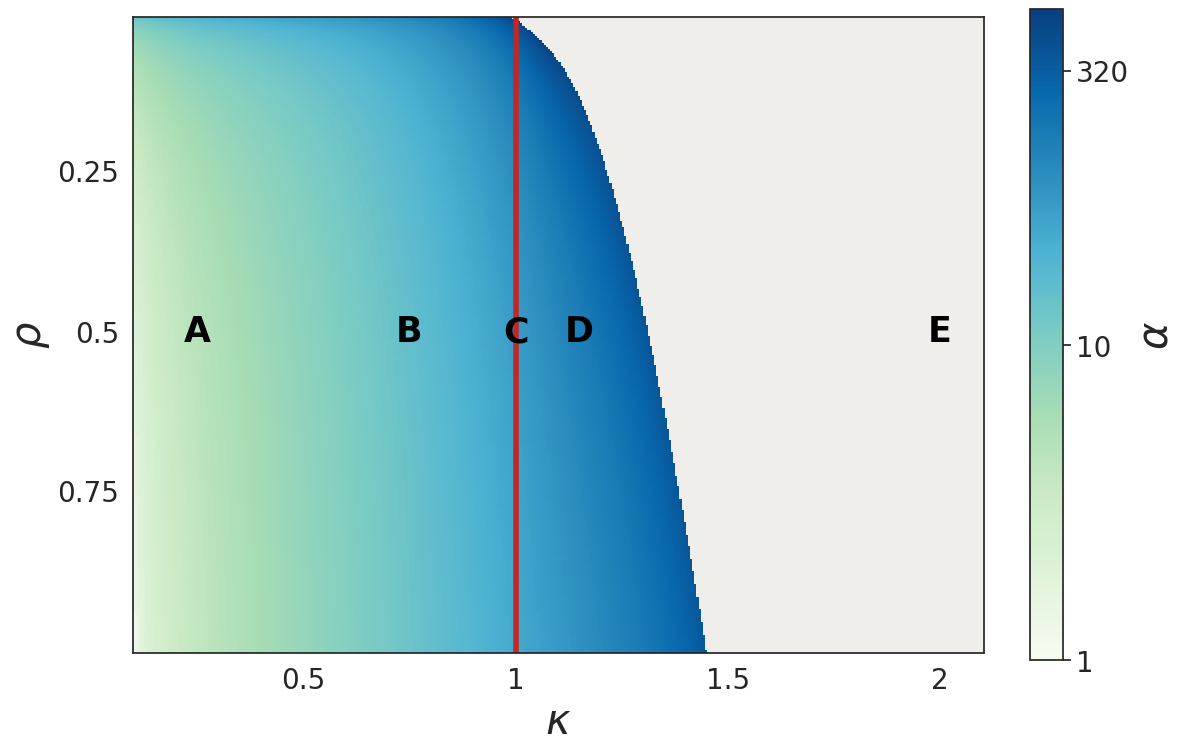

In [ ]:
value = 0
masked_array = np.ma.masked_where(mins_icl_20 == value, mins_icl_20)
cmap = matplotlib.cm.GnBu # Can be any colormap that you want after the cm
cmap.set_bad(color='#EFEEEA')

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the data using imshow
im = ax.imshow(masked_array, cmap=cmap, norm=PowerNorm(gamma=0.5))#, norm=LogNorm(vmin=np.min(masked_array[masked_array > 0]), vmax=np.max(masked_array)))
rhocoord = np.abs(rhos - 0.5).argmin()
coordinates = [(np.abs(kappas - 0.25).argmin(), rhocoord), (np.abs(kappas - 0.75).argmin(), rhocoord), (np.abs(kappas - 1).argmin(), rhocoord), (np.abs(kappas - 1.15).argmin(), rhocoord), (np.abs(kappas - 2).argmin(),rhocoord)]  # Example: (row, column) coordinates
labels = ['A', 'B', 'C', 'D', 'E']
for (x, y), label in zip(coordinates, labels):
    ax.text(x, y, label, ha='center', va='center', color='black', fontsize=25, fontweight='bold')

# Create the colorbar with the same height as the plot
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.05)
cbar.ax.set_yticks([200,300,450])  # Remove ticks
cbar.ax.set_yticklabels([1,10,320])  # Remove tick labels
cbar.ax.set_ylabel(r'$\alpha$')

xvals = [0.5,1,1.5,2]
indsx = [np.abs(kappas - val).argmin() for val in xvals]
yvals = [0.25,0.5,0.75]
indsy = [np.abs(rhos - val).argmin() for val in yvals]

plt.xticks(ticks=indsx, labels=xvals)
plt.yticks(ticks=indsy, labels=yvals)
plt.xticks(fontsize=20);
plt.yticks(fontsize=20);
cbar.ax.tick_params(labelsize=20)  # Set the desired font size
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$\rho$')

tau=20
plt.axvline(np.abs(kappas - np.min([tau,1])).argmin(),linestyle='-',linewidth=4,color='#BF2828',label=r'min($\tau$,1)')

plt.savefig("nonmonotonic_ICL_20.pdf", bbox_inches='tight')
files.download("nonmonotonic_ICL_20.pdf")